Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original Dataset:
Train images : 810
Train masks  : 810
Val images   : 200
Val masks    : 200

After split:
Training: 810
Validation: 150
Test: 50
Train batches: 102
Val batches  : 19
Test batches : 7
Using device: cuda

TRAINING BASELINE MODEL (Dice Loss Only)

Epoch [1/30]
  Train: Loss=0.9503 | Dice=0.1341 | IoU=0.0752
  Val:   Loss=0.9471 | Dice=0.2250 | IoU=0.1286
  Val:   Prec=0.1287 | Rec=0.9978 | Spec=0.9251 | LR=0.000300

Epoch [2/30]
  Train: Loss=0.9352 | Dice=0.3874 | IoU=0.2495
  Val:   Loss=0.9395 | Dice=0.2911 | IoU=0.1723
  Val:   Prec=0.1724 | Rec=0.9964 | Spec=0.9474 | LR=0.000300

Epoch [3/30]
  Train: Loss=0.9262 | Dice=0.4649 | IoU=0.3144
  Val:   Loss=0.9301 | Dice=0.3597 | IoU=0.2217
  Val:   Prec=0.2218 | Rec=0.9977 | Spec=0.9612 | LR=0.000300

Epoch [4/30]
  Train: Loss=0.9125 | Dice=0.5523 | IoU=0.3973
  Val:   Loss=0.9130 | Dice=0.6

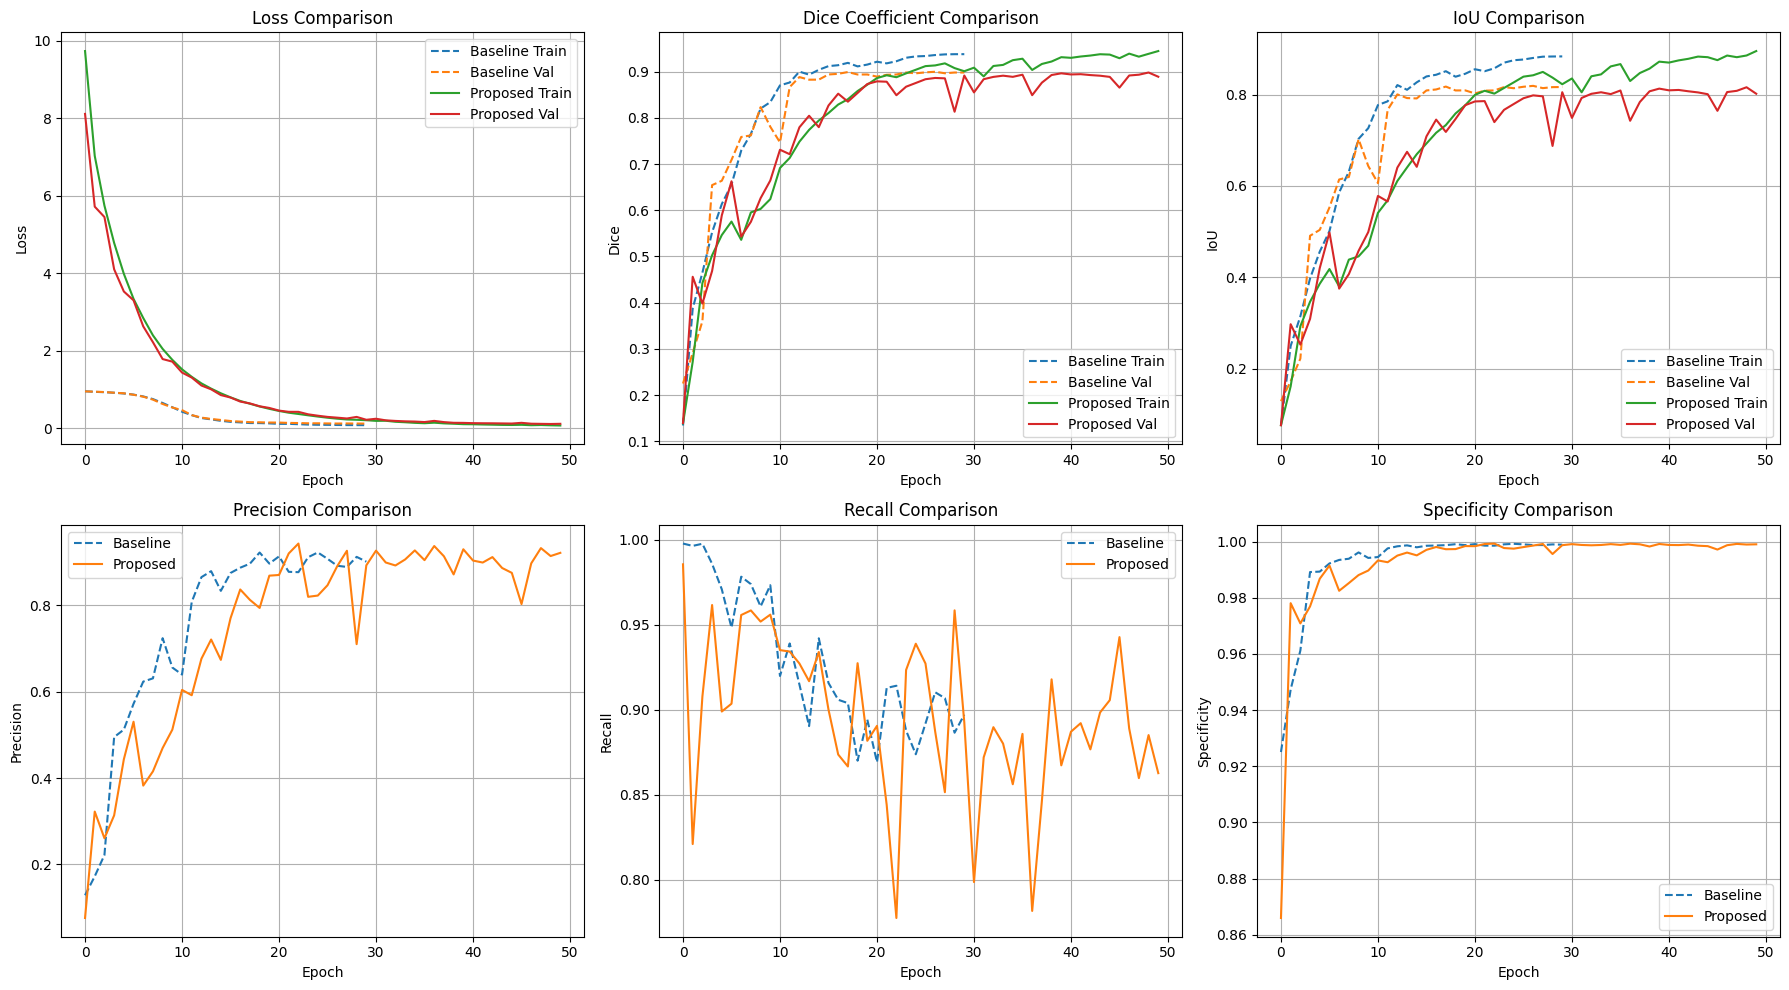

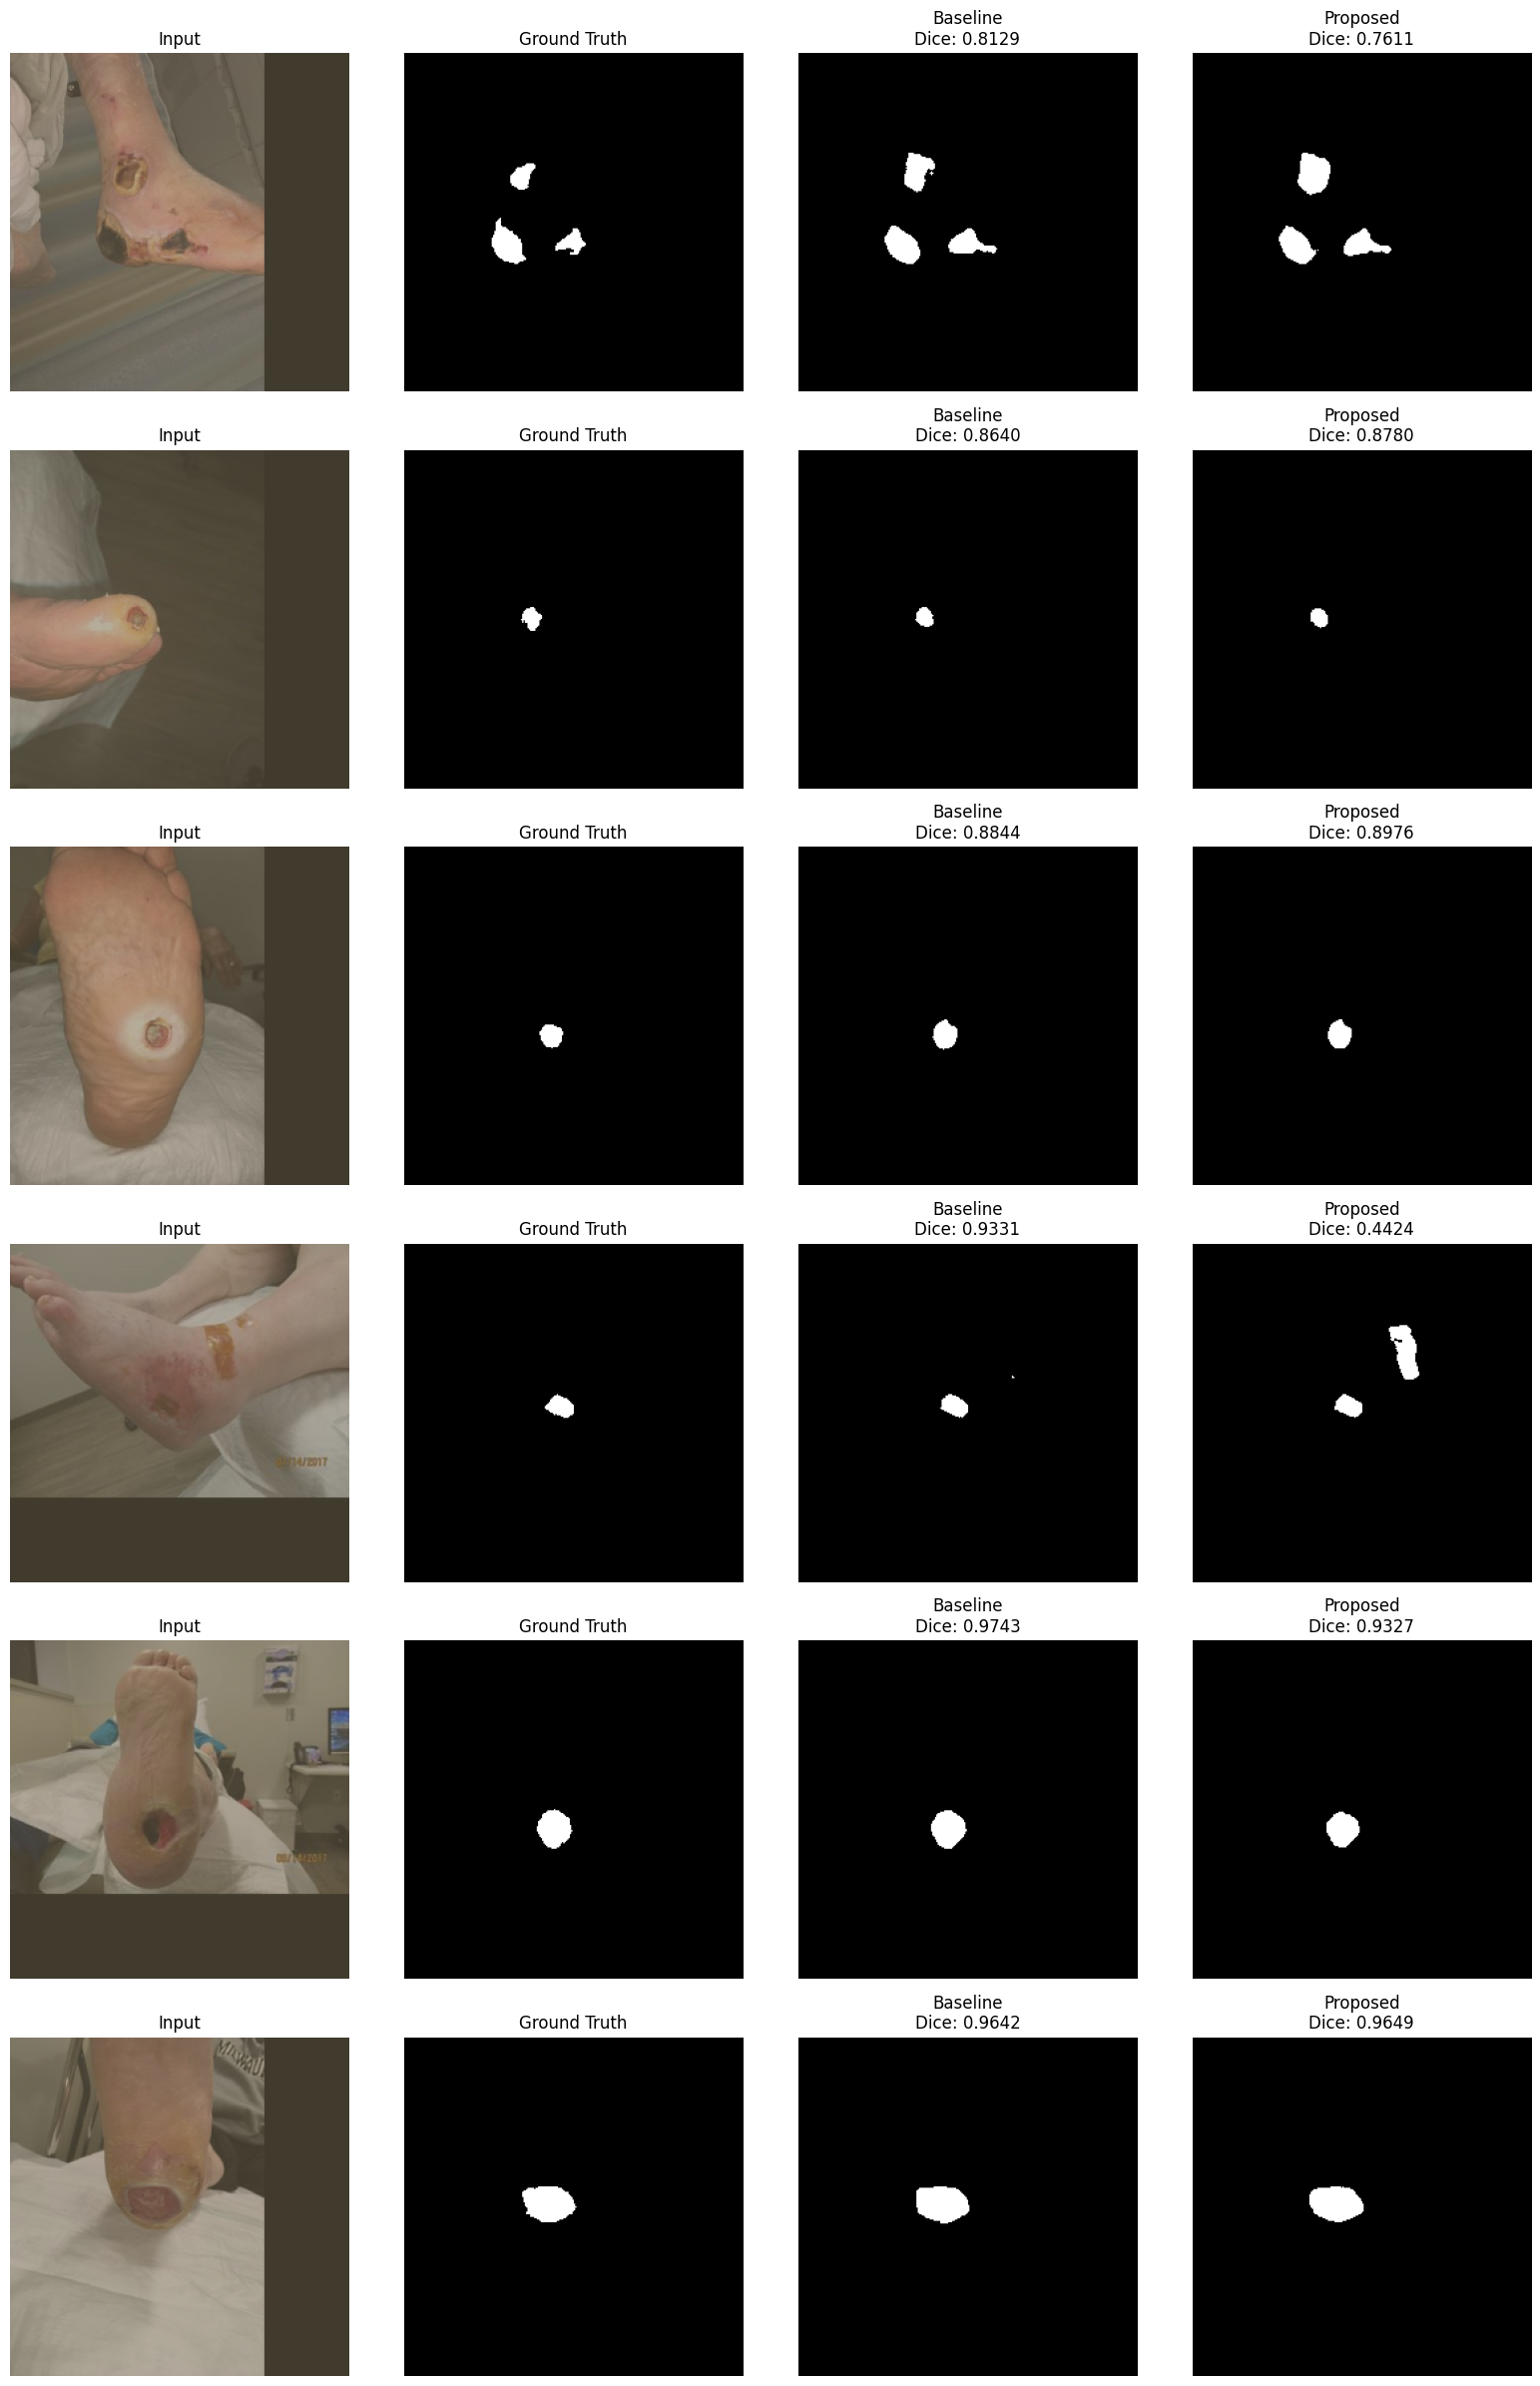

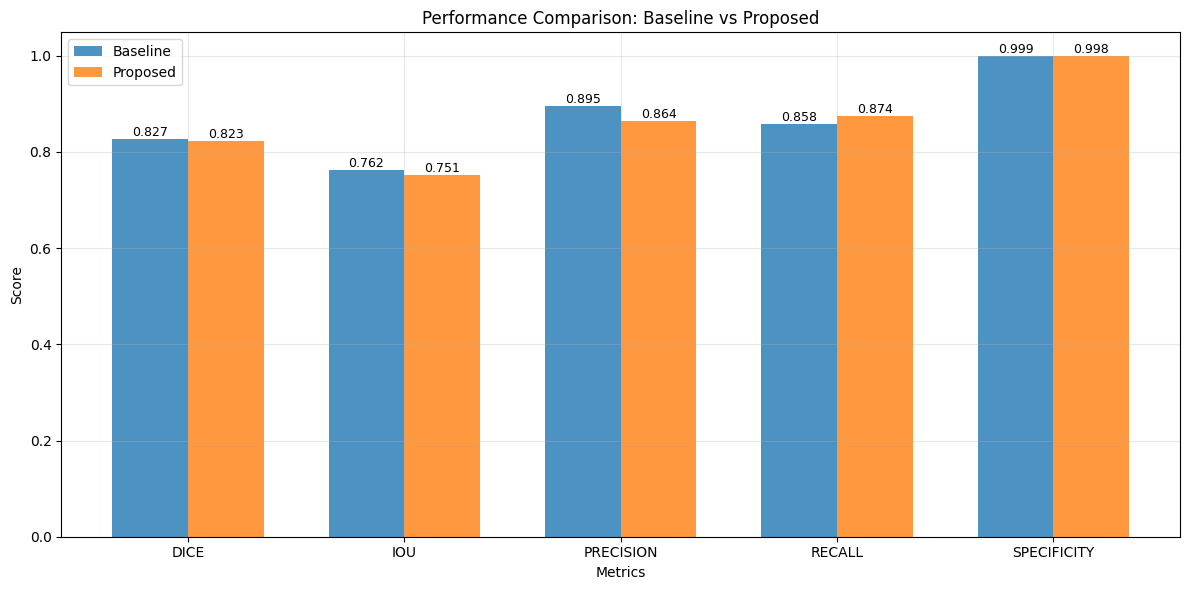

Saved: baseline_model.pth
Saved: proposed_model.pth
Saved: comparison_results.csv
Saved: training_comparison.png
Saved: visual_comparison.png
Saved: metrics_comparison.png

All results saved to: /content/drive/MyDrive/Tugas Akhir_Riodino Raihan_Bismillah /TA_Results

TRAINING AND EVALUATION COMPLETE!


In [ ]:
# ===================================================================
# COMPLETE TRAINING CODE FOR TA - WITH IMPROVEMENTS
# Segmentasi Ulkus Kaki Berbasis U-Net dan EfficientNet-B0
# dengan Boundary Refinement
# ===================================================================

# ===== CELL 1: Install Libraries =====
!pip install -q albumentations opencv-python scipy pandas


# ===== CELL 2: Import Libraries =====
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import efficientnet_b0
import scipy.ndimage as ndi
from scipy.spatial.distance import directed_hausdorff


# ===== CELL 3: Mount Google Drive =====
from google.colab import drive
drive.mount('/content/drive')


# ===== CELL 4: Dataset Paths =====
BASE_DIR = "/content/drive/MyDrive/Tugas Akhir_Riodino Raihan_Bismillah "

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train/labels")

VAL_IMG_DIR = os.path.join(BASE_DIR, "validation/images")
VAL_MASK_DIR = os.path.join(BASE_DIR, "validation/labels")

print("Original Dataset:")
print(f"Train images : {len(os.listdir(TRAIN_IMG_DIR))}")
print(f"Train masks  : {len(os.listdir(TRAIN_MASK_DIR))}")
print(f"Val images   : {len(os.listdir(VAL_IMG_DIR))}")
print(f"Val masks    : {len(os.listdir(VAL_MASK_DIR))}")


# ===== CELL 5: Create Test Set from Validation =====
# We'll split validation into val (150) and test (50)
val_images = sorted(os.listdir(VAL_IMG_DIR))
val_imgs, test_imgs = train_test_split(val_images, test_size=0.25, random_state=42)

print(f"\nAfter split:")
print(f"Training: {len(os.listdir(TRAIN_IMG_DIR))}")
print(f"Validation: {len(val_imgs)}")
print(f"Test: {len(test_imgs)}")


# ===== CELL 6: Dataset Class =====
class FootUlcerDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_list=None, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = image_list if image_list else sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return image, mask


# ===== Cell 7: FIXED Data Augmentation =====
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])


# ===== CELL 8: Create DataLoaders =====
train_dataset = FootUlcerDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform)
val_dataset = FootUlcerDataset(VAL_IMG_DIR, VAL_MASK_DIR, image_list=val_imgs, transform=val_transform)
test_dataset = FootUlcerDataset(VAL_IMG_DIR, VAL_MASK_DIR, image_list=test_imgs, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


# ===== CELL 9: Model Architecture =====
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNetEfficientNetB0(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        backbone = efficientnet_b0(weights="IMAGENET1K_V1")
        self.encoder = backbone.features

        self.dec4 = DecoderBlock(1280, 112, 256)
        self.dec3 = DecoderBlock(256, 40, 128)
        self.dec2 = DecoderBlock(128, 24, 64)
        self.dec1 = DecoderBlock(64, 16, 32)
        self.dec0 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        features = []
        for layer in self.encoder:
            x = layer(x)
            features.append(x)

        e1 = features[1]
        e2 = features[2]
        e3 = features[3]
        e4 = features[5]
        e5 = features[-1]

        d4 = self.dec4(e5, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        d0 = self.dec0(d1)

        return torch.sigmoid(self.final_conv(d0))


# ===== CELL 10: Loss Functions =====
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = preds.view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice


class BoundaryLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, targets):
        preds = preds.squeeze(1)
        targets = targets.squeeze(1)

        boundary_targets = []
        for t in targets.cpu().numpy():
            dist_map = ndi.distance_transform_edt(1 - t)
            boundary_targets.append(dist_map)

        boundary_targets = torch.tensor(
            np.stack(boundary_targets), dtype=torch.float32, device=preds.device
        )
        return torch.mean(preds * boundary_targets)


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.dice = DiceLoss()
        self.boundary = BoundaryLoss()
        self.alpha = alpha

    def forward(self, preds, targets):
        return self.alpha * self.dice(preds, targets) + (1 - self.alpha) * self.boundary(preds, targets)


# ===== CELL 11: Metrics Functions =====
def dice_coefficient(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return ((2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)).item()


def iou_score(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()


def precision_recall_specificity(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float().view(-1).cpu().numpy()
    targets = targets.view(-1).cpu().numpy()

    tp = ((preds == 1) & (targets == 1)).sum()
    fp = ((preds == 1) & (targets == 0)).sum()
    tn = ((preds == 0) & (targets == 0)).sum()
    fn = ((preds == 0) & (targets == 1)).sum()

    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)

    return precision, recall, specificity


def hausdorff_distance(pred, target):
    pred = (pred > 0.5).cpu().numpy()
    target = target.cpu().numpy()

    pred_points = np.argwhere(pred)
    target_points = np.argwhere(target)

    if len(pred_points) == 0 or len(target_points) == 0:
        return None

    return max(
        directed_hausdorff(pred_points, target_points)[0],
        directed_hausdorff(target_points, pred_points)[0]
    )


# ===== CELL 12: Training Functions =====
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    metrics = {'dice': 0, 'iou': 0}

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        metrics['dice'] += dice_coefficient(outputs.detach(), masks)
        metrics['iou'] += iou_score(outputs.detach(), masks)

    n = len(loader)
    return epoch_loss / n, metrics['dice'] / n, metrics['iou'] / n


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    metrics = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0, 'specificity': 0}

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            epoch_loss += criterion(outputs, masks).item()
            metrics['dice'] += dice_coefficient(outputs, masks)
            metrics['iou'] += iou_score(outputs, masks)

            prec, rec, spec = precision_recall_specificity(outputs, masks)
            metrics['precision'] += prec
            metrics['recall'] += rec
            metrics['specificity'] += spec

    n = len(loader)
    return {k: v / n for k, v in {**{'loss': epoch_loss}, **metrics}.items()}


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, save_path):
    best_val_dice = 0
    best_epoch = 0
    history = {
        'train_loss': [], 'train_dice': [], 'train_iou': [],
        'val_loss': [], 'val_dice': [], 'val_iou': [],
        'val_precision': [], 'val_recall': [], 'val_specificity': [], 'lr': []
    }

    for epoch in range(num_epochs):
        train_loss, train_dice, train_iou = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(val_metrics['dice'])
        current_lr = optimizer.param_groups[0]['lr']

        for k in ['train_loss', 'train_dice', 'train_iou']:
            history[k].append(locals()[k])
        for k, v in val_metrics.items():
            history[f'val_{k}'].append(v)
        history['lr'].append(current_lr)

        if val_metrics['dice'] > best_val_dice:
            best_val_dice = val_metrics['dice']
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train: Loss={train_loss:.4f} | Dice={train_dice:.4f} | IoU={train_iou:.4f}")
        print(f"  Val:   Loss={val_metrics['loss']:.4f} | Dice={val_metrics['dice']:.4f} | IoU={val_metrics['iou']:.4f}")
        print(f"  Val:   Prec={val_metrics['precision']:.4f} | Rec={val_metrics['recall']:.4f} | Spec={val_metrics['specificity']:.4f} | LR={current_lr:.6f}\n")

    print(f"Best Val Dice: {best_val_dice:.4f} at Epoch {best_epoch}")
    return history, best_val_dice, best_epoch


# ===== CELL 13: Evaluation Function =====
def evaluate_model(model, loader, device):
    model.eval()
    metrics = {'dice': [], 'iou': [], 'precision': [], 'recall': [], 'specificity': [], 'hausdorff': []}

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            for i in range(outputs.shape[0]):
                metrics['dice'].append(dice_coefficient(outputs[i], masks[i]))
                metrics['iou'].append(iou_score(outputs[i], masks[i]))

                prec, rec, spec = precision_recall_specificity(outputs[i], masks[i])
                metrics['precision'].append(prec)
                metrics['recall'].append(rec)
                metrics['specificity'].append(spec)

                hd = hausdorff_distance(outputs[i][0], masks[i][0])
                if hd is not None:
                    metrics['hausdorff'].append(hd)

    results = {}
    for key, values in metrics.items():
        results[f'{key}_mean'] = np.mean(values)
        results[f'{key}_std'] = np.std(values)

    return results


# ===== CELL 14: Setup Device =====
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


# ===== Cell 15: FIXED Baseline Training =====
print("\n" + "="*80)
print("TRAINING BASELINE MODEL (Dice Loss Only)")
print("="*80 + "\n")

baseline_model = UNetEfficientNetB0().to(device)
baseline_criterion = DiceLoss()
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=3e-4, weight_decay=1e-5)  # Higher LR
baseline_scheduler = ReduceLROnPlateau(baseline_optimizer, mode='max', factor=0.5, patience=5)

baseline_history, baseline_best_dice, baseline_best_epoch = train_model(
    baseline_model, train_loader, val_loader, baseline_criterion, baseline_optimizer,
    baseline_scheduler, num_epochs=30, device=device, save_path="baseline_model.pth"  # 30 epochs untuk test
)


# ===== CELL 16: PROPOSED MODEL (FIXED) =====
print("\n" + "="*80)
print("TRAINING PROPOSED MODEL (Combined Loss with Boundary Refinement)")
print("="*80 + "\n")

proposed_model = UNetEfficientNetB0().to(device)
proposed_criterion = CombinedLoss(alpha=0.7)

# ← FIX: Naikkan LR sama dengan baseline!
proposed_optimizer = optim.Adam(proposed_model.parameters(), lr=3e-4, weight_decay=1e-5)
proposed_scheduler = ReduceLROnPlateau(proposed_optimizer, mode='max', factor=0.5, patience=5)

proposed_history, proposed_best_dice, proposed_best_epoch = train_model(
    proposed_model, train_loader, val_loader, proposed_criterion, proposed_optimizer,
    proposed_scheduler, num_epochs=50, device=device, save_path="proposed_model.pth"
)

# ===== CELL 17: Load Best Models =====
baseline_model.load_state_dict(torch.load("baseline_model.pth"))
proposed_model.load_state_dict(torch.load("proposed_model.pth"))

baseline_model.eval()
proposed_model.eval()


# ===== CELL 18: Test Set Evaluation =====
print("\n" + "="*80)
print("TEST SET EVALUATION")
print("="*80 + "\n")

print("Evaluating Baseline Model on Test Set...")
baseline_test_results = evaluate_model(baseline_model, test_loader, device)

print("Evaluating Proposed Model on Test Set...")
proposed_test_results = evaluate_model(proposed_model, test_loader, device)


# ===== CELL 19: Print Results =====
print("\n" + "="*80)
print("BASELINE MODEL - TEST RESULTS")
print("="*80)
for key, value in baseline_test_results.items():
    print(f"{key:20s}: {value:.4f}")

print("\n" + "="*80)
print("PROPOSED MODEL - TEST RESULTS")
print("="*80)
for key, value in proposed_test_results.items():
    print(f"{key:20s}: {value:.4f}")


# ===== CELL 20: Comparison Table =====
metrics = ['dice', 'iou', 'precision', 'recall', 'specificity', 'hausdorff']

comparison_data = {
    'Metric': [m.upper() for m in metrics],
    'Baseline (Mean±Std)': [
        f"{baseline_test_results[f'{m}_mean']:.4f}±{baseline_test_results[f'{m}_std']:.4f}"
        for m in metrics
    ],
    'Proposed (Mean±Std)': [
        f"{proposed_test_results[f'{m}_mean']:.4f}±{proposed_test_results[f'{m}_std']:.4f}"
        for m in metrics
    ],
    'Improvement': [
        f"{(proposed_test_results[f'{m}_mean'] - baseline_test_results[f'{m}_mean']):.4f} "
        f"({((proposed_test_results[f'{m}_mean'] - baseline_test_results[f'{m}_mean']) / baseline_test_results[f'{m}_mean'] * 100):.2f}%)"
        for m in metrics
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("COMPARISON TABLE: BASELINE vs PROPOSED METHOD")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80 + "\n")

# Save to CSV
comparison_df.to_csv("comparison_results.csv", index=False)
print("Results saved to: comparison_results.csv")


# ===== CELL 21: Plot Training Curves Comparison =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(baseline_history['train_loss'], label='Baseline Train', linestyle='--')
axes[0, 0].plot(baseline_history['val_loss'], label='Baseline Val', linestyle='--')
axes[0, 0].plot(proposed_history['train_loss'], label='Proposed Train')
axes[0, 0].plot(proposed_history['val_loss'], label='Proposed Val')
axes[0, 0].set_title('Loss Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Dice
axes[0, 1].plot(baseline_history['train_dice'], label='Baseline Train', linestyle='--')
axes[0, 1].plot(baseline_history['val_dice'], label='Baseline Val', linestyle='--')
axes[0, 1].plot(proposed_history['train_dice'], label='Proposed Train')
axes[0, 1].plot(proposed_history['val_dice'], label='Proposed Val')
axes[0, 1].set_title('Dice Coefficient Comparison')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Dice')
axes[0, 1].legend()
axes[0, 1].grid(True)

# IoU
axes[0, 2].plot(baseline_history['train_iou'], label='Baseline Train', linestyle='--')
axes[0, 2].plot(baseline_history['val_iou'], label='Baseline Val', linestyle='--')
axes[0, 2].plot(proposed_history['train_iou'], label='Proposed Train')
axes[0, 2].plot(proposed_history['val_iou'], label='Proposed Val')
axes[0, 2].set_title('IoU Comparison')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('IoU')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Precision
axes[1, 0].plot(baseline_history['val_precision'], label='Baseline', linestyle='--')
axes[1, 0].plot(proposed_history['val_precision'], label='Proposed')
axes[1, 0].set_title('Precision Comparison')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(baseline_history['val_recall'], label='Baseline', linestyle='--')
axes[1, 1].plot(proposed_history['val_recall'], label='Proposed')
axes[1, 1].set_title('Recall Comparison')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Specificity
axes[1, 2].plot(baseline_history['val_specificity'], label='Baseline', linestyle='--')
axes[1, 2].plot(proposed_history['val_specificity'], label='Proposed')
axes[1, 2].set_title('Specificity Comparison')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Specificity')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig("training_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# ===== CELL 22: Visualize Predictions (Baseline vs Proposed) =====
def visualize_comparison(baseline_model, proposed_model, dataset, device, num_samples=6):
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for idx, data_idx in enumerate(indices):
            image, mask = dataset[data_idx]
            image_input = image.unsqueeze(0).to(device)

            baseline_pred = baseline_model(image_input).squeeze().cpu().numpy()
            proposed_pred = proposed_model(image_input).squeeze().cpu().numpy()
            mask = mask.squeeze().cpu().numpy()

            # Denormalize
            img_display = image.permute(1, 2, 0).cpu().numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)

            # Plot
            axes[idx, 0].imshow(img_display)
            axes[idx, 0].set_title('Input')
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(mask, cmap='gray')
            axes[idx, 1].set_title('Ground Truth')
            axes[idx, 1].axis('off')

            baseline_dice = dice_coefficient(torch.tensor(baseline_pred), torch.tensor(mask))
            axes[idx, 2].imshow(baseline_pred > 0.5, cmap='gray')
            axes[idx, 2].set_title(f'Baseline\nDice: {baseline_dice:.4f}')
            axes[idx, 2].axis('off')

            proposed_dice = dice_coefficient(torch.tensor(proposed_pred), torch.tensor(mask))
            axes[idx, 3].imshow(proposed_pred > 0.5, cmap='gray')
            axes[idx, 3].set_title(f'Proposed\nDice: {proposed_dice:.4f}')
            axes[idx, 3].axis('off')

    plt.tight_layout()
    plt.savefig("visual_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

visualize_comparison(baseline_model, proposed_model, test_dataset, device, num_samples=6)


# ===== CELL 23: Bar Chart Comparison =====
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

metrics_to_plot = ['dice', 'iou', 'precision', 'recall', 'specificity']
x = np.arange(len(metrics_to_plot))
width = 0.35

baseline_values = [baseline_test_results[f'{m}_mean'] for m in metrics_to_plot]
proposed_values = [proposed_test_results[f'{m}_mean'] for m in metrics_to_plot]

bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8)
bars2 = ax.bar(x + width/2, proposed_values, width, label='Proposed', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Baseline vs Proposed')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# ===== CELL 24: Save All Results to Drive =====
import shutil

# Create results folder
results_dir = os.path.join(BASE_DIR, "TA_Results")
os.makedirs(results_dir, exist_ok=True)

# Copy all results
files_to_save = [
    "baseline_model.pth",
    "proposed_model.pth",
    "comparison_results.csv",
    "training_comparison.png",
    "visual_comparison.png",
    "metrics_comparison.png"
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, os.path.join(results_dir, file))
        print(f"Saved: {file}")

print(f"\nAll results saved to: {results_dir}")

print("\n" + "="*80)
print("TRAINING AND EVALUATION COMPLETE!")
print("="*80)

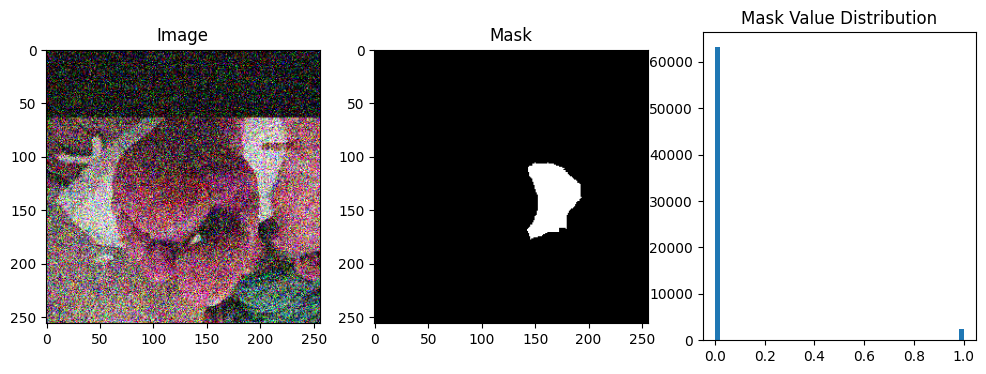

Mask shape: torch.Size([1, 256, 256])
Mask min: 0.0, max: 1.0
Mask unique values: tensor([0., 1.])
Percentage of ulcer pixels: 3.55%


In [ ]:
# Tambahkan cell ini untuk check data
import matplotlib.pyplot as plt

image, mask = train_dataset[0]
plt.figure(figsize=(12, 4))

# Denormalize image
img = image.permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Image')

plt.subplot(1, 3, 2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title('Mask')

plt.subplot(1, 3, 3)
plt.hist(mask.numpy().flatten(), bins=50)
plt.title('Mask Value Distribution')
plt.show()

print(f"Mask shape: {mask.shape}")
print(f"Mask min: {mask.min()}, max: {mask.max()}")
print(f"Mask unique values: {torch.unique(mask)}")
print(f"Percentage of ulcer pixels: {(mask.sum() / mask.numel() * 100):.2f}%")
# ```

# **Expected output:**
# - Mask harus binary (0 dan 1 saja)
# - Ulcer pixels sekitar 5-20% dari total
# - Image dan mask harus match

# ---

# ## 🚨 Action Plan SEKARANG:
# ```
# 1. ❌ STOP training yang sedang jalan
# 2. ✅ Implement FIX 1-4 di atas
# 3. ✅ Re-run dari Cell 1 sampai Cell 15 (dengan epochs=10)
# 4. ✅ Check hasil setelah 10 epochs:
#    - Kalau Dice > 0.50 → Lanjut ke 50 epochs
#    - Kalau masih < 0.30 → Ada masalah di data

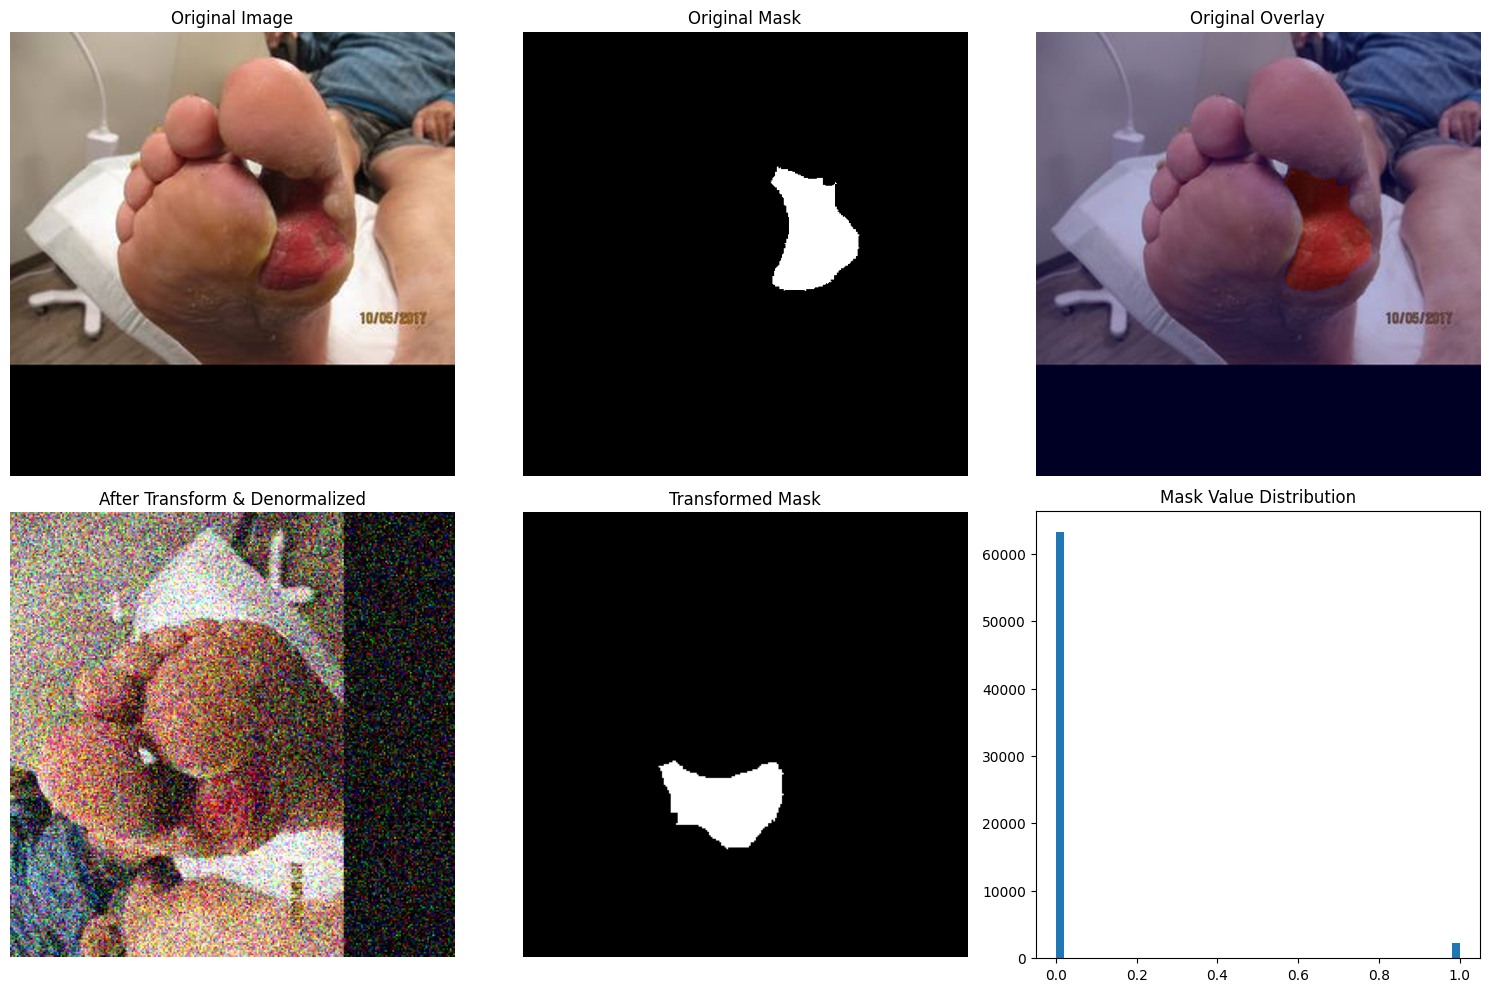

Original Image shape: (512, 512, 3)
Transformed Image shape: torch.Size([3, 256, 256])
Original Mask shape: (512, 512)
Transformed Mask shape: torch.Size([1, 256, 256])

Mask stats:
  Min: 0.0, Max: 1.0
  Unique values: tensor([0., 1.])
  Ulcer pixels: 3.55%

Image stats (after denorm):
  Min: 0, Max: 254


In [ ]:
# ===== CEK DATA (FIXED VERSION) =====
import matplotlib.pyplot as plt
import cv2

# Load raw image (tanpa transform)
img_path = os.path.join(TRAIN_IMG_DIR, sorted(os.listdir(TRAIN_IMG_DIR))[0])
mask_path = os.path.join(TRAIN_MASK_DIR, sorted(os.listdir(TRAIN_MASK_DIR))[0])

raw_image = cv2.imread(img_path)
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)

raw_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
raw_mask = (raw_mask > 0).astype(np.float32)

# Get transformed version
image, mask = train_dataset[0]

# Denormalize CORRECTLY
img_display = image.permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = (img_display * std + mean) * 255  # ← KEY FIX!
img_display = np.clip(img_display, 0, 255).astype(np.uint8)

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original (before transform)
axes[0, 0].imshow(raw_image)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(raw_mask, cmap='gray')
axes[0, 1].set_title('Original Mask')
axes[0, 1].axis('off')

axes[0, 2].imshow(raw_image)
axes[0, 2].imshow(raw_mask, cmap='jet', alpha=0.3)
axes[0, 2].set_title('Original Overlay')
axes[0, 2].axis('off')

# Row 2: After transform
axes[1, 0].imshow(img_display)
axes[1, 0].set_title('After Transform & Denormalized')
axes[1, 0].axis('off')

axes[1, 1].imshow(mask.squeeze(), cmap='gray')
axes[1, 1].set_title('Transformed Mask')
axes[1, 1].axis('off')

axes[1, 2].hist(mask.numpy().flatten(), bins=50)
axes[1, 2].set_title('Mask Value Distribution')

plt.tight_layout()
plt.show()

# Print stats
print(f"Original Image shape: {raw_image.shape}")
print(f"Transformed Image shape: {image.shape}")
print(f"Original Mask shape: {raw_mask.shape}")
print(f"Transformed Mask shape: {mask.shape}")
print(f"\nMask stats:")
print(f"  Min: {mask.min()}, Max: {mask.max()}")
print(f"  Unique values: {torch.unique(mask)}")
print(f"  Ulcer pixels: {(mask.sum() / mask.numel() * 100):.2f}%")
print(f"\nImage stats (after denorm):")
print(f"  Min: {img_display.min()}, Max: {img_display.max()}")